In [23]:
import os

import numpy as np

import matplotlib.pyplot as plt 

import tensorflow as tf
import tensorflow.keras as keras
from keras import layers, models, callbacks


from qkeras import QActivation, QConv2D, QDense
from qkeras import quantized_bits, quantized_relu
from qkeras.utils import model_save_quantized_weights

import hls4ml

tf.random.set_seed(69)
np.random.seed(69)

In [24]:
# Set up quantization params
W_precise = quantized_bits(8, 1, alpha=1) # Range [-2, 2] -> hls4ml fixed<8,2>
W_std = quantized_bits(4, 0, alpha=1) # Range [-1, 1] -> hls4ml fixed<4,1>

# profiling shows we need range up to 3.0
A_precise = "quantized_relu(8,2)" # 2 integer bits + sign = Range [0, 4]
A_std = "quantized_relu(4,1)" # 1 integer bit + sign = Range [0, 2]
A_out = "quantized_relu(8,0)"

def build_q_tiny_spatial_autoencoder(input_shape=(64, 64, 1)):
    # Encoder section
    input_img = layers.Input(shape=input_shape)
 
    # 2 small conv layers to capture essential features while keeping fpga resource usage low
    # Use explicit activations layers in qkeras to allow maximal op splitting/tiling
    x = QConv2D(4, (3, 3), padding="same",
                kernel_quantizer=W_precise, bias_quantizer=W_precise,
                name="enc_conv1")(input_img)
    x = QActivation(A_precise, name="enc_act1")(x)
    x = layers.MaxPooling2D((2, 2), padding="same", name="enc_pool1")(x)
 
    x = QConv2D(4, (3, 3), padding="same",
                kernel_quantizer=W_precise, bias_quantizer=W_precise,
                name="enc_conv2")(x)
    x = QActivation(A_precise, name="enc_act2")(x)
    x = layers.MaxPooling2D((2, 2), padding="same", name="enc_pool2")(x) # 16x16x4
 
    # using a spatial (instead of dense) latent space to reduce params because we are hw constrained
    
    # decoder section - construct a spectrogram from the latent representation

    # 32x32x4
    x = QConv2D(4, (3, 3), padding="same",
                         kernel_quantizer=W_std, bias_quantizer=W_std,
                         name="dec_conv1")(x)
    x = QActivation(A_std, name="dec_act1")(x)
    x = layers.UpSampling2D((4, 4), name="dec_up1")(x)
 
    # 64x64x8 cutting layer to save resources
    # x = QConv2D(8, (3, 3), padding="same",
    #                      kernel_quantizer=W_std, bias_quantizer=W_std,
    #                      name="dec_conv2")(x)
    # x = QActivation(A_std, name="dec_act2")(x)
    # x = layers.UpSampling2D((2, 2), name="dec_up2")(x)
 
    x = QConv2D(1, (3, 3), padding="same",
                kernel_quantizer=W_std, bias_quantizer=W_std,
                name="dec_out_conv")(x)
    decoded = QActivation(A_out, name="dec_out_act")(x)
 
    return models.Model(input_img, decoded, name="qat_autoencoder")

In [25]:
def train(x_train, x_val=None, epochs=50, batch_size=32):
    """
    x_train : np.ndarray  shape (N, 64, 64, 1), values in [0, 1]
    x_val   : np.ndarray  shape (M, 64, 64, 1), optional
    """
    model = build_q_tiny_spatial_autoencoder()
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="mae",
    )
    model.summary()
 
    cb = [
        callbacks.EarlyStopping(
            monitor="val_loss" if x_val is not None else "loss",
            patience=10,
            restore_best_weights=True,
            verbose=1,
        ),
    ]
 
    validation_data = (x_val, x_val) if x_val is not None else None
 
    history = model.fit(
        x_train, x_train,   # since we are training the model to recreate the input
        epochs=epochs,
        batch_size=batch_size,
        validation_data=validation_data,
        callbacks=cb, # there seems to be a bug with this tf/keras version where saving the model as .keras throws an error
        shuffle=True,
    )
 
    return model, history

In [26]:
def spectrogram_to_tensor(spectrogram, window_size=64, step_size=32):
    # we want to create windows 64 wide 
    _ , steps = spectrogram.shape
    windows = []
    for start in range(0, steps - window_size + 1, step_size):
            window = spectrogram[:, start : start + window_size]
            windows.append(window)
    
    X = np.array(windows)
    X = np.expand_dims(X, axis=-1)
    return X

def create_dataset(data_dir, file = None, window_size=64, step_size=32):
    all_windows = []
    if file is not None:
        files = [file]
    else:
        files = [f for f in os.listdir(data_dir) if f.endswith('.npy')]
    
    for f in files:
        spec = np.load(os.path.join(data_dir, f))
        
        all_windows.append(spectrogram_to_tensor(spec, window_size, step_size))

    X = np.concatenate(all_windows, axis=0)
    np.random.shuffle(X)
    return X

X_train = create_dataset('../data/spectrogram/normal/')

# use 20% of data for validation
split = int(0.8 * len(X_train))
train_data = X_train[:split]
val_data = X_train[split:]

print(f"Total training windows: {len(train_data)}")

Total training windows: 6835


In [26]:
model, history = train(train_data, val_data, epochs=50, batch_size=32)

Model: "qat_autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 64, 64, 1)]       0         
                                                                 
 enc_conv1 (QConv2D)         (None, 64, 64, 4)         40        
                                                                 
 enc_act1 (QActivation)      (None, 64, 64, 4)         0         
                                                                 
 enc_pool1 (MaxPooling2D)    (None, 32, 32, 4)         0         
                                                                 
 enc_conv2 (QConv2D)         (None, 32, 32, 4)         148       
                                                                 
 enc_act2 (QActivation)      (None, 32, 32, 4)         0         
                                                                 
 enc_pool2 (MaxPooling2D)    (None, 16, 16, 4)     

2026-04-16 10:00:58.964470: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape ingradient_tape/qat_autoencoder/dec_out_act/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


214/214 [==============================] - 6s 19ms/step - loss: 0.1452 - val_loss: 0.1174
Epoch 2/50
214/214 [==============================] - 3s 13ms/step - loss: 0.1009 - val_loss: 0.0801
Epoch 3/50
214/214 [==============================] - 3s 14ms/step - loss: 0.0889 - val_loss: 0.0855
Epoch 4/50
214/214 [==============================] - 3s 13ms/step - loss: 0.0841 - val_loss: 0.0852
Epoch 5/50
214/214 [==============================] - 3s 12ms/step - loss: 0.0712 - val_loss: 0.0633
Epoch 6/50
214/214 [==============================] - 2s 12ms/step - loss: 0.0665 - val_loss: 0.0899
Epoch 7/50
214/214 [==============================] - 3s 12ms/step - loss: 0.0693 - val_loss: 0.0864
Epoch 8/50
214/214 [==============================] - 3s 12ms/step - loss: 0.0687 - val_loss: 0.0594
Epoch 9/50
214/214 [==============================] - 3s 12ms/step - loss: 0.0616 - val_loss: 0.0610
Epoch 10/50
214/214 [==============================] - 3s 13ms/step - loss: 0.0595 - val_loss: 0.0565


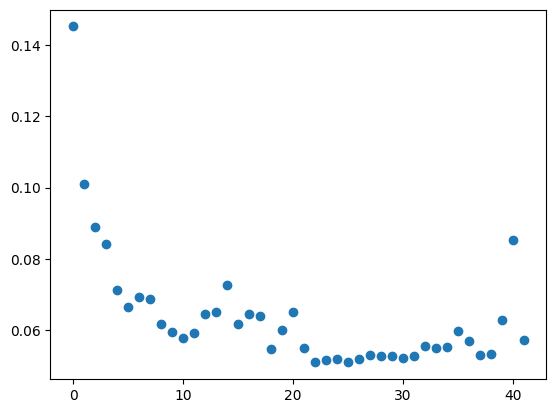

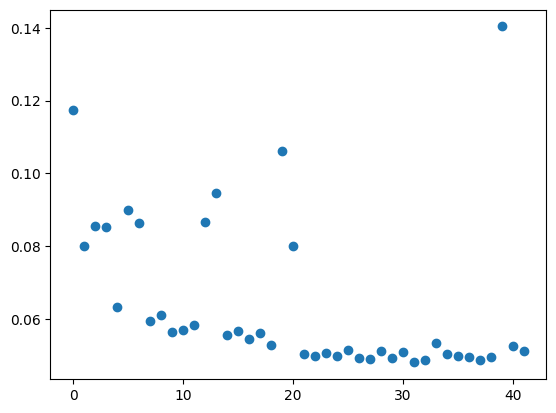

In [27]:
plt.scatter(range(len(history.history['loss'])), history.history['loss'], label='Train Loss')
plt.figure()
plt.scatter(range(len(history.history['val_loss'])), history.history['val_loss'], label='Validation Loss')

In [39]:
model.save('q_tiny_spatial_autoencoder.keras')
model.save_weights("q_tiny_spatial_autoencoder_weights.h5")

/home/ericraze/miniconda3/envs/hls_gpu/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


In [28]:
%run audio.ipynb

def detect_anomalies(file_path, model, threshold=0.05):
    # make spectrograms of nhwc (c = 1)
    spec = generate_fpga_style_spectrogram(file_path) # (64, 313)
    windows = spectrogram_to_tensor(spec) 
    
    # predict and calc error
    reconstructed = model.predict(windows)
    errors = np.mean(np.abs(windows - reconstructed), axis=(1, 2, 3))
    anomalous_indices = np.where(errors > threshold)[0]
    
    return errors, anomalous_indices

In [29]:
# Test on new files and quantify how our model does on normal and abnormal data
normal_path = '../-6_dB_slider/slider/id_02/normal/'
abnormal_path = '../-6_dB_slider/slider/id_02/abnormal/'

n_files = 25

normal_files = [f for f in os.listdir(normal_path) if f.endswith('.wav')]
abnormal_files = [f for f in os.listdir(abnormal_path) if f.endswith('.wav')]

normal_errors = []
abnormal_errors = []

for idx, f in enumerate(normal_files):
    if idx >= n_files:
        break
    errors, _ = detect_anomalies(os.path.join(normal_path, f), model)
    normal_errors.append(errors)
    
for idx, f in enumerate(abnormal_files):
    if idx >= n_files:
        break
    errors, _ = detect_anomalies(os.path.join(abnormal_path, f), model)
    abnormal_errors.append(errors)

normal_errors = np.array(normal_errors)
abnormal_errors = np.array(abnormal_errors)

print(f"normal error mean: {normal_errors.mean()} std dev: {normal_errors.std()}")
print(f"abnormal error mean: {abnormal_errors.mean()} std dev: {abnormal_errors.std()}")


1/1 [==============================] - 0s 36ms/step
normal error mean: 0.04898086562752724 std dev: 0.010550327599048615
abnormal error mean: 0.05896559730172157 std dev: 0.0075263227336108685


In [27]:
model = build_q_tiny_spatial_autoencoder()
model.load_weights('q_tiny_spatial_autoencoder_weights.h5')

In [30]:
import hls4ml
config = hls4ml.utils.config_from_keras_model(
     model,
     granularity='name',
     backend='Vitis')

config['Model']['Strategy'] = 'Resource'
config['Model']['ReuseFactor'] = 64
config['Model']['BramFactor'] = 256 # Will need to play around with the array size cutoff

for layer in config['LayerName'].keys():
    # 1. Protect the Summation
    # Using 16 bits for accumulation is "safe" and usually still fits in 1 DSP if ReuseFactor is high.
    if 'conv' in layer:
        config['LayerName'][layer]['Precision']['accum'] = 'fixed<16,6>'
        config['LayerName'][layer]['ReuseFactor'] = 128
        config['LayerName'][layer]['LimitResources'] = True
    
    # 2. Fix the Decoder Clipping
    # dec_conv1 hit -4.76. We need at least 3 integer bits (sign + 2^2 + 2^1)
    if 'dec_conv1' in layer:
        config['LayerName'][layer]['Precision']['result'] = 'fixed<8,4>'
        config['LayerName'][layer]['Precision']['accum']  = 'fixed<16,6>'

    if 'input' in layer:
        config['LayerName'][layer]['Precision']['result'] = 'ufixed<8,0>'

config['LayerName']['enc_conv1']['Precision']['weight'] = 'fixed<8,2>'
config['LayerName']['enc_act1']['Precision']['result'] = 'ufixed<8,2>'
config['LayerName']['enc_conv2']['Precision']['weight'] = 'fixed<4,1>'
config['LayerName']['enc_act2']['Precision']['result'] = 'ufixed<6,1>'

Interpreting Model
Topology:
Layer name: input_4, layer type: InputLayer, input shapes: [[None, 64, 64, 1]], output shape: [None, 64, 64, 1]
Layer name: enc_conv1, layer type: QConv2D, input shapes: [[None, 64, 64, 1]], output shape: [None, 64, 64, 4]
Layer name: enc_act1, layer type: Activation, input shapes: [[None, 64, 64, 4]], output shape: [None, 64, 64, 4]
Layer name: enc_pool1, layer type: MaxPooling2D, input shapes: [[None, 64, 64, 4]], output shape: [None, 32, 32, 4]
Layer name: enc_conv2, layer type: QConv2D, input shapes: [[None, 32, 32, 4]], output shape: [None, 32, 32, 4]
Layer name: enc_act2, layer type: Activation, input shapes: [[None, 32, 32, 4]], output shape: [None, 32, 32, 4]
Layer name: enc_pool2, layer type: MaxPooling2D, input shapes: [[None, 32, 32, 4]], output shape: [None, 16, 16, 4]
Layer name: dec_conv1, layer type: QConv2D, input shapes: [[None, 16, 16, 4]], output shape: [None, 16, 16, 4]
Layer name: dec_act1, layer type: Activation, input shapes: [[None, 

In [31]:
hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config,
    output_dir='../../FPGA-Audio-Failure-Analyzer/model_hls_output',
    io_type='io_stream',
    backend='Vitis',
    part='xc7a35tcpg236-1',
    clock_period=10,
)
hls_model.write()
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True)

Interpreting Model
Topology:
Layer name: input_4, layer type: InputLayer, input shapes: [[None, 64, 64, 1]], output shape: [None, 64, 64, 1]
Layer name: enc_conv1, layer type: QConv2D, input shapes: [[None, 64, 64, 1]], output shape: [None, 64, 64, 4]
Layer name: enc_act1, layer type: Activation, input shapes: [[None, 64, 64, 4]], output shape: [None, 64, 64, 4]
Layer name: enc_pool1, layer type: MaxPooling2D, input shapes: [[None, 64, 64, 4]], output shape: [None, 32, 32, 4]
Layer name: enc_conv2, layer type: QConv2D, input shapes: [[None, 32, 32, 4]], output shape: [None, 32, 32, 4]
Layer name: enc_act2, layer type: Activation, input shapes: [[None, 32, 32, 4]], output shape: [None, 32, 32, 4]
Layer name: enc_pool2, layer type: MaxPooling2D, input shapes: [[None, 32, 32, 4]], output shape: [None, 16, 16, 4]
Layer name: dec_conv1, layer type: QConv2D, input shapes: [[None, 16, 16, 4]], output shape: [None, 16, 16, 4]
Layer name: dec_act1, layer type: Activation, input shapes: [[None, 

In [32]:
# run the vitis hls pipeline
hls_model.build(csim=False, export=True, vsynth=True)

sh: /home/ericraze/miniconda3/envs/hls_gpu/lib/libtinfo.so.6: no version information available (required by sh)
sh: /home/ericraze/miniconda3/envs/hls_gpu/lib/libtinfo.so.6: no version information available (required by sh)
/bin/bash: /home/ericraze/miniconda3/envs/hls_gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)


/bin/bash: /home/ericraze/miniconda3/envs/hls_gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
/bin/bash: /home/ericraze/miniconda3/envs/hls_gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2024.2 (64-bit)
  **** SW Build 5238294 on Nov  8 2024
  **** IP Build 5239520 on Sun Nov 10 16:12:51 MST 2024
  **** SharedData Build 5239561 on Fri Nov 08 14:39:27 MST 2024
  **** Start of session at: Thu Apr 16 20:35:17 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis/2024.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] For user 'ericraze' on host 'Ericraze.localdomain' (Linux_x86_64 version 6.6.87.2-microsoft-standard-WSL2) on Thu Apr 16 20:35:20 CST 2026
INFO: [HLS 200-10] On os Ubuntu 22.04.3 LTS
INFO: [HLS 200-10] In directory '/mnt/c/Users

{'CSimResults': [['0.125',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.140625',
   '0.109375',
   '0.09375',

In [33]:
# verify the accuracy of our hls model in cpp sim
hls_model.compile()

# get a batch of test windows, then run both models 
X_test = val_data[:100]  # shape (100, 64, 64, 1)
keras_out = model.predict(X_test)
hls_out = hls_model.predict(X_test)

# check results
mae = np.mean(np.abs(keras_out.flatten() - hls_out.flatten()))
max_err = np.max(np.abs(keras_out.flatten() - hls_out.flatten()))
print(f"Mean absolute error: {mae:.6f}")
print(f"Max absolute error:  {max_err:.6f}")

Writing HLS project


/home/ericraze/miniconda3/envs/hls_gpu/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
/home/ericraze/miniconda3/envs/hls_gpu/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


Done


sh: /home/ericraze/miniconda3/envs/hls_gpu/lib/libtinfo.so.6: no version information available (required by sh)
bash: /home/ericraze/miniconda3/envs/hls_gpu/lib/libtinfo.so.6: no version information available (required by bash)


4/4 [==============================] - 0s 15ms/step
Mean absolute error: 0.031087
Max absolute error:  0.218750


4/4 [==============================] - 0s 16ms/step
Layer Name           | Min      | Max      | % Clipped (>1.0)
------------------------------------------------------------
input_4              |    0.000 |    1.000 |           0.00%
enc_conv1            |   -2.670 |    1.327 |           1.06%
enc_act1             |    0.000 |    1.328 |           0.97%
enc_pool1            |    0.000 |    1.328 |           2.13%
enc_conv2            |   -1.446 |    1.223 |           0.08%
enc_act2             |    0.000 |    1.219 |           0.08%
enc_pool2            |    0.000 |    1.219 |           0.24%
dec_conv1            |   -1.529 |    1.480 |           5.12%
dec_act1             |    0.000 |    1.500 |           3.76%
dec_up1              |    0.000 |    1.500 |           3.76%
dec_out_conv         |    0.031 |    1.062 |           0.00%
dec_out_act          |    0.031 |    0.996 |           0.00%


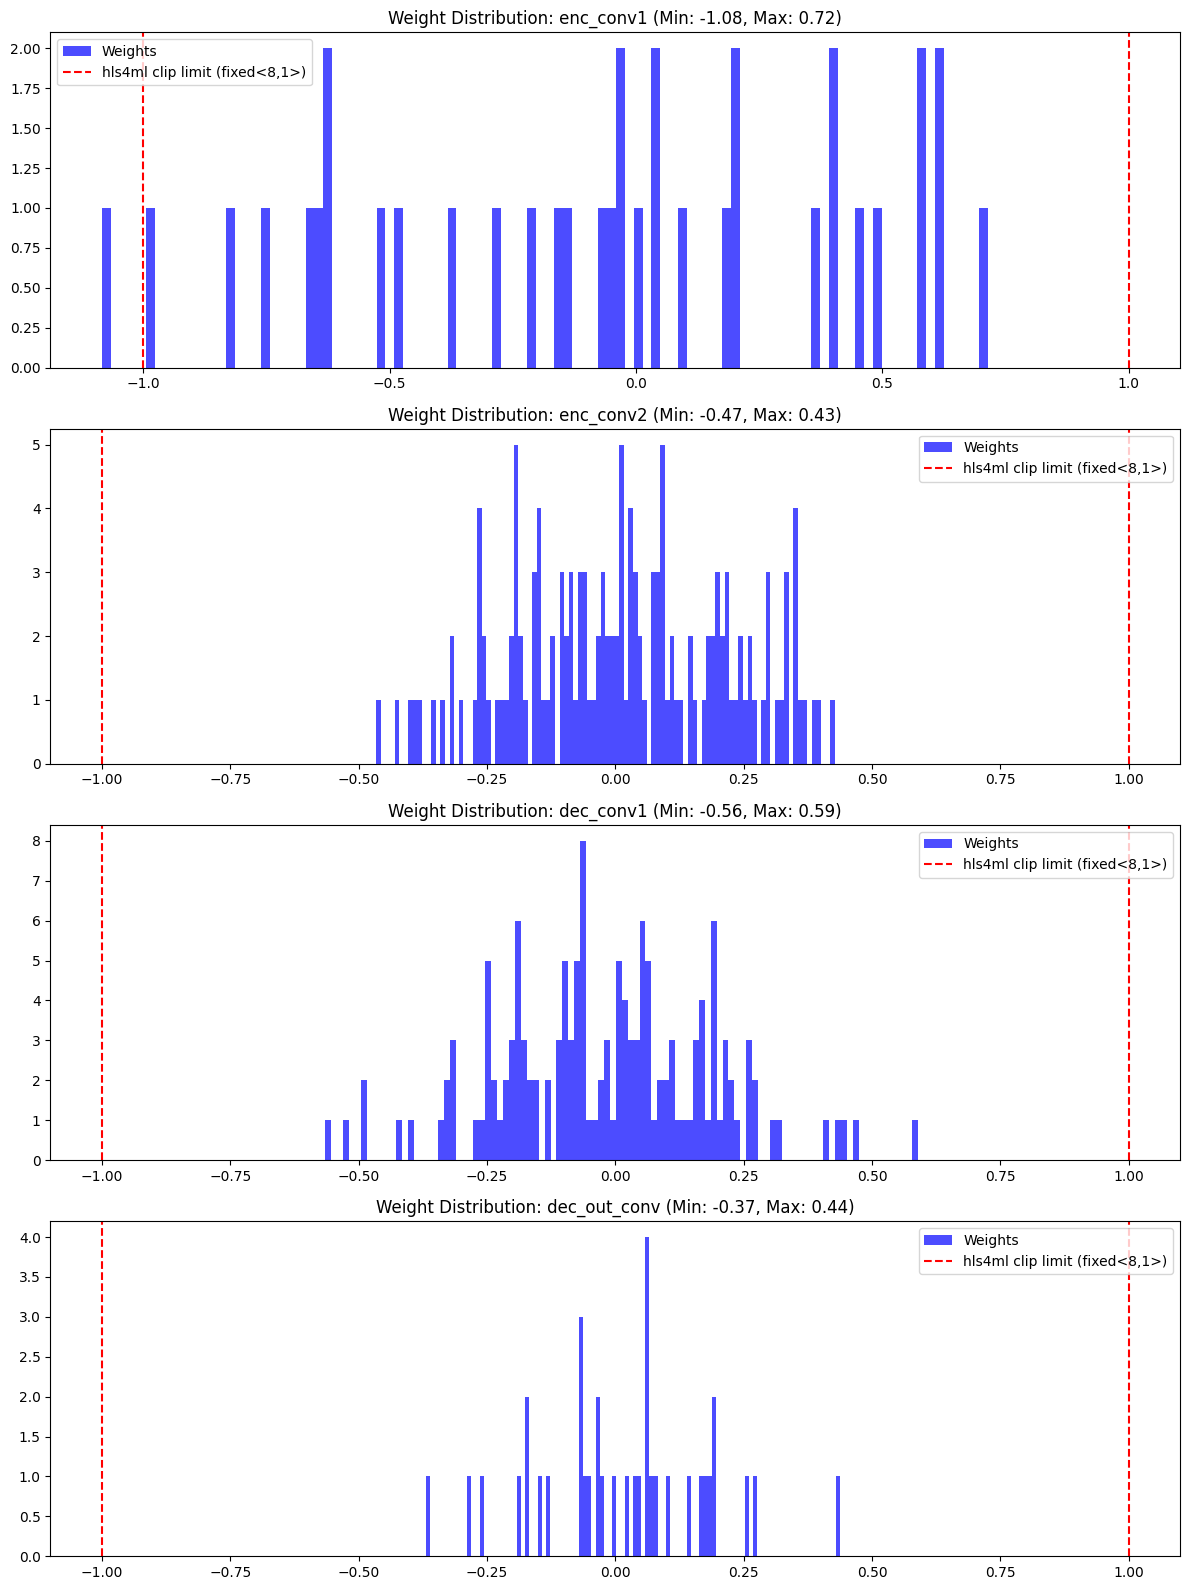

In [34]:
# gemini script to debug accuracy loss between training and deployment
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import models

def analyze_quantization(model, X_sample):
    """
    Analyzes weights and activations to find clipping issues.
    """
    # 1. Analyze Weights
    weight_layers = [l for l in model.layers if hasattr(l, 'get_weights') and len(l.get_weights()) > 0]
    
    plt.figure(figsize=(12, 4 * len(weight_layers)))
    for i, layer in enumerate(weight_layers):
        weights = layer.get_weights()[0].flatten()
        plt.subplot(len(weight_layers), 1, i+1)
        plt.hist(weights, bins=100, alpha=0.7, color='blue', label='Weights')
        
        # Draw the hls4ml 'fixed<8,1>' boundaries
        plt.axvline(x=1.0, color='red', linestyle='--', label='hls4ml clip limit (fixed<8,1>)')
        plt.axvline(x=-1.0, color='red', linestyle='--')
        
        plt.title(f"Weight Distribution: {layer.name} (Min: {weights.min():.2f}, Max: {weights.max():.2f})")
        plt.legend()
    plt.tight_layout()
    plt.savefig('weight_distributions.png')
    
    # 2. Profile Activations
    # Create a model that outputs every layer's activation
    layer_outputs = [layer.output for layer in model.layers]
    activation_model = models.Model(inputs=model.input, outputs=layer_outputs)
    activations = activation_model.predict(X_sample)
    
    print(f"{'Layer Name':<20} | {'Min':<8} | {'Max':<8} | {'% Clipped (>1.0)':<15}")
    print("-" * 60)
    
    for layer, act in zip(model.layers, activations):
        act_flat = act.flatten()
        clipped_pct = np.mean(act_flat > 1.0) * 100
        print(f"{layer.name:<20} | {act.min():8.3f} | {act.max():8.3f} | {clipped_pct:14.2f}%")

# Run the analysis
# Assuming 'model' is your trained QKeras model and 'X_test' is your sample data
analyze_quantization(model, X_test[:100])